In [24]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
results_dir = project_root / "results"

small_results = pd.read_csv(results_dir / "small_results.csv")
medium_results = pd.read_csv(results_dir / "medium_results.csv")
large_results = pd.read_csv(results_dir / "large_results.csv")

results = pd.concat(
    [small_results, medium_results, large_results],
    ignore_index=True
)

print("Ukupno rezultata:", len(results))

Ukupno rezultata: 400


In [25]:
# Ujednačavanje naziva CPLEX algoritma
results["Algorithm"] = results["Algorithm"].replace({
    "CPLEX": "ILP (CPLEX)"
})

time_summary = (
    results
    .groupby(["n", "Algorithm"])["Time (s)"]
    .mean()
    .reset_index()
)

time_summary

,n,Algorithm,Time (s)
0,10,Brute Force,0.001103
1,10,Genetic Algorithm,0.130804
2,10,Greedy,0.000094
3,10,Tabu Search,0.001794
4,15,Brute Force,0.050218
5,15,Genetic Algorithm,0.141506
6,15,Greedy,0.000167
7,15,Tabu Search,0.002267
8,20,Brute Force,2.282651
9,20,Genetic Algorithm,0.155184


In [26]:
time_pivot = time_summary.pivot(
    index="n",
    columns="Algorithm",
    values="Time (s)"
)

time_pivot

Algorithm,Brute Force,Genetic Algorithm,Greedy,ILP (CPLEX),Tabu Search
n,,,,,
10,0.001103,0.130804,0.000094,NaN,0.001794
15,0.050218,0.141506,0.000167,NaN,0.002267
20,2.282651,0.155184,0.000250,NaN,0.003192
25,NaN,0.168708,0.000420,0.007137,0.004603
30,NaN,0.182929,0.000644,0.015518,0.005637
40,NaN,0.215664,0.000973,0.024760,0.008752
50,NaN,0.254581,0.001537,0.077980,0.012676
75,NaN,1.208928,0.003370,0.120305,0.021778
100,NaN,1.666921,0.006313,0.005910,0.030976


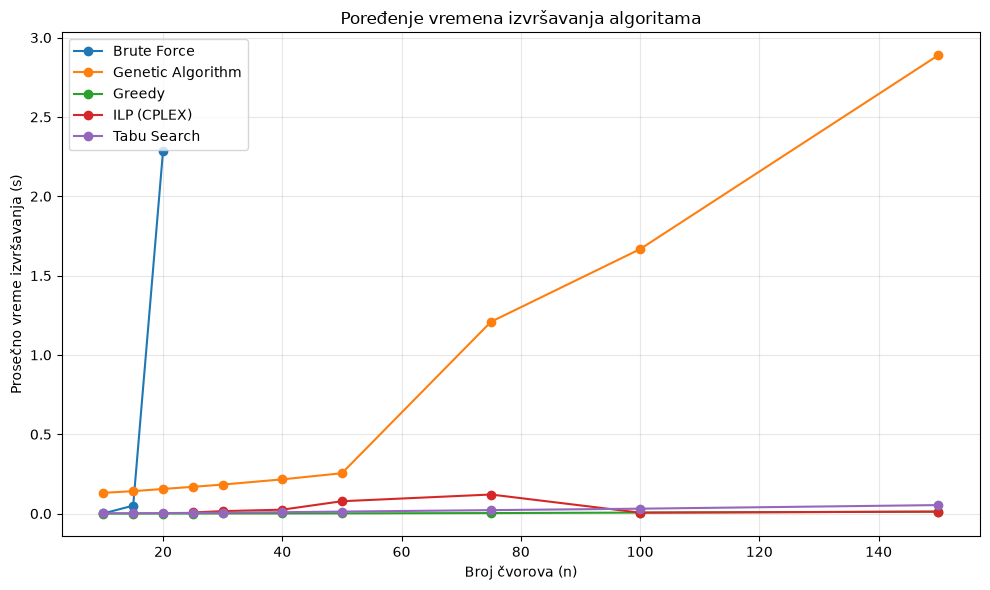

Grafikon je sačuvan u: /home/hpdeb/Documents/RI/maximum-independent-set/results/execution_time_comparison.png


In [27]:
plt.figure(figsize=(10, 6))

for algorithm in time_pivot.columns:
    plt.plot(
        time_pivot.index,
        time_pivot[algorithm],
        marker="o",
        label=algorithm
    )

plt.xlabel("Broj čvorova (n)")
plt.ylabel("Prosečno vreme izvršavanja (s)")
plt.title("Poređenje vremena izvršavanja algoritama")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

output_path = results_dir / "execution_time_comparison.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Grafikon je sačuvan u: {output_path}")

### Poređenje vremena izvršavanja

Za poređenje efikasnosti algoritama posmatrano je prosečno vreme izvršavanja u zavisnosti od veličine instance, odnosno broja čvorova $n$. Za svaku veličinu instance izračunato je prosečno vreme izvršavanja algoritma.

Zbog značajnih razlika u vremenima izvršavanja između algoritama, na y-osi grafikona koristi se logaritamska skala. Na taj način moguće je jasnije prikazati ponašanje svih algoritama, od najbržeg pohlepnog algoritma do sporijih algoritama.